# 05 - Event-Study Setup

## Purpose

This notebook constructs the first serious **event-study / interrupted-time-series setup** for the thesis question around PDUFA and controlled-substance composition.

The notebook is intentionally conservative. Its job is not to force a paper-ready causal claim. Its job is to:

1. build the annual outcome series that the current FDA+DEA data can actually support
2. justify the main sample and outcome definition
3. inspect whether the annual series are stable enough for an event-study-style workflow
4. run simple, transparent first-pass break specifications around 1992
5. state clearly what these results can and cannot mean

## Main starting hypothesis

Based on the earlier descriptive notebooks, the leading candidate outcome is:

- **annual share of confident scheduled DEA matches within the `ORIG` subset**

But that recommendation still needs to survive direct annualization, denominator diagnostics, and simple break-model checks. The notebook therefore treats it as a starting point rather than as a foregone conclusion.

## Inputs used here

- `data/processed/fda_backbone.csv`
- `data/intermediate/fda_dea_controlled_substance_linkage.csv` if it is materialized locally
- `data/intermediate/fda_dea_active_ingredient_linkage_audit.csv` as the documented fallback needed when the row-level linkage file is only a Git LFS pointer

## Scope and caution

This is a **submission-event-based annual national time series**, not a staggered adoption design and not a product-level controlled-substance panel. The DEA linkage remains **current, ingredient-level, and non-historical**, and the FDA backbone remains **submission-event based** rather than automatically drug-level. Any event-study interpretation here should therefore be understood as a cautious interrupted-time-series style exercise rather than strong causal identification.


## Setup

The first code block only handles imports, path detection, policy-year constants, and a few display defaults. Keeping those pieces explicit up front makes the later annual-series construction easier to audit and reduces the chance that a later cell quietly changes the design.

In [1]:
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    """Walk upward until the thesis repo root is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "logs" / "thesis_context.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the econ580-thesis repository root from the current working directory.")


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = find_repo_root(Path.cwd().resolve())
BACKBONE_PATH = ROOT / "data" / "processed" / "fda_backbone.csv"
LINKED_PATH = ROOT / "data" / "intermediate" / "fda_dea_controlled_substance_linkage.csv"
INGREDIENT_AUDIT_PATH = ROOT / "data" / "intermediate" / "fda_dea_active_ingredient_linkage_audit.csv"
ANNUAL_PANEL_EXPORT_PATH = ROOT / "data" / "intermediate" / "fda_dea_event_study_annual_panel.csv"

KEY_COLS = ["ApplNo", "SubmissionType", "SubmissionNo"]
MAIN_BREAK_YEAR = 1992
CONTEXT_BREAK_YEAR = 1984
PDUFA_RENEWAL_YEARS = [1997, 2002, 2007, 2012, 2017]
DESCRIPTIVE_YEAR_MIN = 1960
ESTIMATION_YEAR_MIN = 1980
YEAR_MAX = 2025
ROLLING_WINDOW = 3

DEA_STATUS_ORDER = [
    "confident_scheduled_controlled_substance_match",
    "list_i_chemical_only_match",
    "possible_parent_or_isomer_candidate_only",
    "no_active_ingredient_available_in_fda_backbone",
    "no_dea_signal_from_first_pass",
]

DEA_STATUS_LABELS = OrderedDict([
    ("confident_scheduled_controlled_substance_match", "Confident scheduled match"),
    ("list_i_chemical_only_match", "List I only"),
    ("possible_parent_or_isomer_candidate_only", "Candidate only / uncertain"),
    ("no_active_ingredient_available_in_fda_backbone", "No active ingredient in FDA backbone"),
    ("no_dea_signal_from_first_pass", "No DEA signal"),
])


## Load the analysis sources and validate the row-level linkage

The notebook should prefer the intended row-level FDA+DEA linkage file if it is actually present as data. But the local repository may only contain a Git LFS pointer instead of the materialized CSV.

If that happens, the notebook should **not** fail silently and should **not** overwrite source files in place. The transparent fallback is to reconstruct the working linked panel **in memory only** by merging the FDA backbone to the ingredient-level linkage audit that was already produced and documented in notebook 03.


In [2]:
def inspect_git_lfs_pointer(path: Path) -> dict:
    """Return metadata if a local file resolves to a Git LFS pointer rather than data."""
    with path.open("r", encoding="utf-8", errors="ignore") as handle:
        first_lines = [handle.readline().strip() for _ in range(3)]
    is_pointer = bool(first_lines) and first_lines[0].startswith("version https://git-lfs.github.com/spec/v1")
    return {
        "path": str(path),
        "exists": path.exists(),
        "is_git_lfs_pointer": is_pointer,
        "pointer_line_1": first_lines[0] if len(first_lines) >= 1 else "",
        "pointer_line_2": first_lines[1] if len(first_lines) >= 2 else "",
        "pointer_line_3": first_lines[2] if len(first_lines) >= 3 else "",
    }


backbone_raw = pd.read_csv(BACKBONE_PATH, low_memory=False)
ingredient_audit = pd.read_csv(INGREDIENT_AUDIT_PATH, low_memory=False)
linked_pointer_meta = inspect_git_lfs_pointer(LINKED_PATH)

if linked_pointer_meta["is_git_lfs_pointer"]:
    linked_raw = None
    linked_source_mode = "reconstructed_in_memory_from_backbone_plus_ingredient_audit"
    analysis_df = backbone_raw.merge(
        ingredient_audit,
        on="ActiveIngredient_list",
        how="left",
        validate="m:1",
    )
else:
    linked_raw = pd.read_csv(LINKED_PATH, low_memory=False)
    linked_source_mode = "loaded_materialized_row_level_linkage_csv"
    analysis_df = linked_raw.copy()

for col in KEY_COLS + ["SubmissionType", "SubmissionStatus", "ApplType_clean", "ReviewPriority_clean"]:
    if col in analysis_df.columns:
        analysis_df[col] = analysis_df[col].astype("string").str.strip()

analysis_df["submission_status_year"] = pd.to_numeric(
    analysis_df["submission_status_year"], errors="coerce"
).astype("Int64")

analysis_df["dea_linkage_status"] = analysis_df["dea_linkage_status"].fillna(
    "no_active_ingredient_available_in_fda_backbone"
).astype("string")

for flag_col in [
    "dea_confident_controlled_match_flag",
    "dea_list_i_only_match_flag",
    "dea_possible_candidate_only_flag",
    "dea_uncertain_flag",
]:
    if flag_col in analysis_df.columns:
        analysis_df[flag_col] = analysis_df[flag_col].fillna(False).astype(bool)

source_summary = pd.DataFrame([
    {
        "dataset": "FDA backbone",
        "path": str(BACKBONE_PATH),
        "rows": len(backbone_raw),
        "columns": backbone_raw.shape[1],
        "status": "loaded",
        "note": "authoritative submission-event panel",
    },
    {
        "dataset": "FDA+DEA row-level linkage",
        "path": str(LINKED_PATH),
        "rows": len(linked_raw) if linked_raw is not None else pd.NA,
        "columns": linked_raw.shape[1] if linked_raw is not None else pd.NA,
        "status": "git-lfs-pointer" if linked_raw is None else "loaded",
        "note": linked_source_mode,
    },
    {
        "dataset": "Ingredient-level DEA audit",
        "path": str(INGREDIENT_AUDIT_PATH),
        "rows": len(ingredient_audit),
        "columns": ingredient_audit.shape[1],
        "status": "loaded",
        "note": "used only as documented fallback / audit layer",
    },
])

validation_summary = pd.DataFrame([
    {"check": "Backbone duplicate submission-event keys", "value": int(backbone_raw.duplicated(KEY_COLS).sum())},
    {"check": "Working dataframe duplicate submission-event keys", "value": int(analysis_df.duplicated(KEY_COLS).sum())},
    {"check": "Working dataframe row-count minus backbone row-count", "value": int(len(analysis_df) - len(backbone_raw))},
    {"check": "Rows with missing DEA linkage status after explicit fill", "value": int(analysis_df["dea_linkage_status"].isna().sum())},
    {"check": "Rows with missing ActiveIngredient_list", "value": int(analysis_df["ActiveIngredient_list"].isna().sum())},
])

if int(analysis_df.duplicated(KEY_COLS).sum()) != 0:
    raise ValueError("The working dataframe is not unique on the submission-event key.")

if len(analysis_df) != len(backbone_raw):
    raise ValueError("The working dataframe no longer matches the FDA backbone row count.")

display(source_summary)
display(validation_summary)


,dataset,path,rows,columns,status,note
0,FDA backbone,/Users/alexdelatorre/Desktop/econ580-thesis/da...,191265,59,loaded,authoritative submission-event panel
1,FDA+DEA row-level linkage,/Users/alexdelatorre/Desktop/econ580-thesis/da...,<NA>,<NA>,git-lfs-pointer,reconstructed_in_memory_from_backbone_plus_ing...
2,Ingredient-level DEA audit,/Users/alexdelatorre/Desktop/econ580-thesis/da...,3202,23,loaded,used only as documented fallback / audit layer


,check,value
0,Backbone duplicate submission-event keys,0
1,Working dataframe duplicate submission-event keys,0
2,Working dataframe row-count minus backbone row...,0
3,Rows with missing DEA linkage status after exp...,0
4,Rows with missing ActiveIngredient_list,5737


### Interpretation

The notebook now has a validated working linked panel.

In the current local working tree, the intended row-level linkage file is still only a **Git LFS pointer**, so the notebook reconstructs the row-level linkage **in memory only** from the FDA backbone plus the ingredient-level audit. That is the conservative choice because it preserves the repository state while still making the event-study setup reproducible.

The checks above also confirm that:

- the working dataframe still matches the FDA backbone row count
- the submission-event key remains unique
- rows with missing FDA ingredient information are being labeled explicitly rather than disappearing into a generic non-match category


## Rebuild clean analysis categories and define helper functions

The event-study setup needs transparent, auditable categories rather than ad hoc filters scattered across later cells. This block therefore rebuilds:

- FDA sample indicators
- DEA signal tiers
- helper functions for annualization and simple interrupted-time-series models

It also drops **2026** from the analytic window. That is deliberate: the March 2026 extract gives only a partial year, so carrying it into annual break analysis would create an avoidable mechanical artifact.


In [3]:
analysis_df["dea_linkage_status_work"] = pd.Categorical(
    analysis_df["dea_linkage_status"],
    categories=DEA_STATUS_ORDER,
    ordered=True,
)
analysis_df["appl_type_label"] = analysis_df["ApplType_clean"].fillna("UNKNOWN")
analysis_df["submission_type_label"] = analysis_df["SubmissionType"].fillna("MISSING")
analysis_df["submission_status_label"] = analysis_df["SubmissionStatus"].fillna("MISSING")

analysis_df["dea_any_signal_flag"] = analysis_df["dea_linkage_status_work"].isin([
    "confident_scheduled_controlled_substance_match",
    "list_i_chemical_only_match",
    "possible_parent_or_isomer_candidate_only",
])
analysis_df["dea_confident_plus_list_i_flag"] = analysis_df["dea_linkage_status_work"].isin([
    "confident_scheduled_controlled_substance_match",
    "list_i_chemical_only_match",
])
analysis_df["dea_confident_only_flag"] = analysis_df["dea_linkage_status_work"].eq(
    "confident_scheduled_controlled_substance_match"
)

SAMPLE_DEFINITIONS = OrderedDict([
    ("full_panel", {
        "label": "Full panel",
        "description": "all submission-event rows",
        "mask": pd.Series(True, index=analysis_df.index),
    }),
    ("ap_only", {
        "label": "AP only",
        "description": "rows where `is_approved == True`",
        "mask": analysis_df["is_approved"].fillna(False),
    }),
    ("orig_only", {
        "label": "ORIG only",
        "description": "rows where `is_original_submission == True`",
        "mask": analysis_df["is_original_submission"].fillna(False),
    }),
    ("orig_plus_ap", {
        "label": "ORIG + AP",
        "description": "rows where `is_original_submission == True` or `is_approved == True`",
        "mask": analysis_df["is_original_submission"].fillna(False) | analysis_df["is_approved"].fillna(False),
    }),
    ("orig_nda_only", {
        "label": "ORIG + NDA only",
        "description": "original submission rows where `ApplType_clean == NDA`",
        "mask": analysis_df["is_original_submission"].fillna(False) & analysis_df["ApplType_clean"].eq("NDA"),
    }),
])

SERIES_SPECS = OrderedDict([
    ("orig_confident", {
        "label": "ORIG confident scheduled share",
        "sample_key": "orig_only",
        "status_set": ["confident_scheduled_controlled_substance_match"],
    }),
    ("ap_confident", {
        "label": "AP confident scheduled share",
        "sample_key": "ap_only",
        "status_set": ["confident_scheduled_controlled_substance_match"],
    }),
    ("orig_nda_confident", {
        "label": "ORIG + NDA-only confident scheduled share",
        "sample_key": "orig_nda_only",
        "status_set": ["confident_scheduled_controlled_substance_match"],
    }),
    ("orig_confident_plus_list_i", {
        "label": "ORIG confident + List I share",
        "sample_key": "orig_only",
        "status_set": [
            "confident_scheduled_controlled_substance_match",
            "list_i_chemical_only_match",
        ],
    }),
    ("orig_any_signal", {
        "label": "ORIG any DEA signal share",
        "sample_key": "orig_only",
        "status_set": [
            "confident_scheduled_controlled_substance_match",
            "list_i_chemical_only_match",
            "possible_parent_or_isomer_candidate_only",
        ],
    }),
])


def add_policy_markers(ax, include_renewals=False):
    ax.axvline(CONTEXT_BREAK_YEAR, color="#555555", linestyle=":", linewidth=1.2, alpha=0.9)
    ax.axvline(MAIN_BREAK_YEAR, color="#111111", linestyle="--", linewidth=1.5, alpha=0.95)
    if include_renewals:
        for year in PDUFA_RENEWAL_YEARS:
            ax.axvline(year, color="#7f7f7f", linestyle="-.", linewidth=1.0, alpha=0.6)


def annualize_series(sample_mask: pd.Series, status_set, year_min=DESCRIPTIVE_YEAR_MIN, year_max=YEAR_MAX) -> pd.DataFrame:
    sample_df = analysis_df.loc[sample_mask].copy()
    sample_df = sample_df.loc[sample_df["submission_status_year"].between(year_min, year_max)].copy()
    sample_df["outcome_flag"] = sample_df["dea_linkage_status_work"].isin(status_set)

    annual = (
        sample_df.groupby("submission_status_year")
        .agg(denominator=("ApplNo", "size"))
        .rename_axis("year")
        .reset_index()
    )
    annual["numerator"] = (
        sample_df.groupby("submission_status_year")["outcome_flag"].sum().astype(int).values
    )
    annual["share"] = annual["numerator"] / annual["denominator"]
    annual = annual.sort_values("year").reset_index(drop=True)
    return annual


def rolling_mean(series: pd.Series, window=ROLLING_WINDOW) -> pd.Series:
    return series.rolling(window=window, center=True, min_periods=1).mean()


def fit_segmented_its(panel: pd.DataFrame, outcome_col: str, break_year: int, year_min: int, year_max: int, maxlags: int = 1):
    model_df = panel.loc[panel["year"].between(year_min, year_max)].copy()
    model_df = model_df.sort_values("year").reset_index(drop=True)
    model_df["time_index"] = np.arange(len(model_df))
    model_df[f"post_{break_year}"] = (model_df["year"] >= break_year).astype(int)
    model_df[f"post_{break_year}_trend"] = np.where(
        model_df["year"] >= break_year,
        model_df["year"] - break_year,
        0,
    )
    X = sm.add_constant(model_df[["time_index", f"post_{break_year}", f"post_{break_year}_trend"]])
    y = model_df[outcome_col]
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    model_df["fitted_value"] = model.predict(X)
    return model_df, model


def extract_model_results(model, series_label: str, break_year: int, window_label: str) -> pd.DataFrame:
    out = model.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    out.insert(0, "series_label", series_label)
    out.insert(1, "break_year", break_year)
    out.insert(2, "window_label", window_label)
    return out


sample_catalog = pd.DataFrame([
    {
        "sample_key": sample_key,
        "sample_label": spec["label"],
        "definition": spec["description"],
        "row_count": int(spec["mask"].sum()),
        "share_of_full_panel": spec["mask"].mean(),
    }
    for sample_key, spec in SAMPLE_DEFINITIONS.items()
])

display(sample_catalog)


,sample_key,sample_label,definition,row_count,share_of_full_panel
0,full_panel,Full panel,all submission-event rows,191265,1.0000
1,ap_only,AP only,rows where `is_approved == True`,190051,0.9937
2,orig_only,ORIG only,rows where `is_original_submission == True`,27434,0.1434
3,orig_plus_ap,ORIG + AP,rows where `is_original_submission == True` or...,191217,0.9997
4,orig_nda_only,ORIG + NDA only,original submission rows where `ApplType_clean...,5453,0.0285


### Interpretation

Two practical choices are already locked in at this stage.

1. **2026 is excluded** from annual event-study work because the extract is only partial through March 2026.
2. The candidate outcome series are built from explicit sample and status definitions rather than from informal notebook state.

That matters because the later modeling cells should be traceable back to visible sample logic, not to a hidden chain of filters.


## Compare the candidate annual outcome series before choosing the main one

The notebook now annualizes the main candidate series and compares them directly.

The purpose is to answer a simple but crucial question before modeling: **which annual series is actually usable?** That requires looking at both shares and denominators. A series can be conceptually appealing and still be too fragile if its denominator is too small or too unstable.


In [4]:
candidate_diagnostics = []
lowest_denominator_rows = []

for series_key, spec in SERIES_SPECS.items():
    annual = annualize_series(
        sample_mask=SAMPLE_DEFINITIONS[spec["sample_key"]]["mask"],
        status_set=spec["status_set"],
        year_min=DESCRIPTIVE_YEAR_MIN,
        year_max=YEAR_MAX,
    )
    annual_est = annual.loc[annual["year"].between(ESTIMATION_YEAR_MIN, YEAR_MAX)].copy()

    candidate_diagnostics.append({
        "series_key": series_key,
        "series_label": spec["label"],
        "sample_label": SAMPLE_DEFINITIONS[spec["sample_key"]]["label"],
        "status_rule": "; ".join(spec["status_set"]),
        "year_min": int(annual["year"].min()),
        "year_max": int(annual["year"].max()),
        "n_estimation_years": len(annual_est),
        "mean_denominator_1980_2025": annual_est["denominator"].mean(),
        "min_denominator_1980_2025": annual_est["denominator"].min(),
        "mean_share_1980_2025": annual_est["share"].mean(),
        "sd_share_1980_2025": annual_est["share"].std(),
        "cv_share_1980_2025": annual_est["share"].std() / annual_est["share"].mean(),
        "mean_share_1980_1992": annual_est.loc[annual_est["year"].between(1980, 1992), "share"].mean(),
        "mean_share_1993_2005": annual_est.loc[annual_est["year"].between(1993, 2005), "share"].mean(),
        "post_minus_pre": annual_est.loc[annual_est["year"].between(1993, 2005), "share"].mean() - annual_est.loc[annual_est["year"].between(1980, 1992), "share"].mean(),
    })

    smallest = annual.nsmallest(5, "denominator").copy()
    smallest.insert(0, "series_label", spec["label"])
    lowest_denominator_rows.append(smallest)

candidate_diagnostics = pd.DataFrame(candidate_diagnostics).sort_values(
    ["cv_share_1980_2025", "mean_denominator_1980_2025"], ascending=[True, False]
)
lowest_denominator_years = pd.concat(lowest_denominator_rows, ignore_index=True)

display(candidate_diagnostics)
display(lowest_denominator_years)


,series_key,series_label,sample_label,status_rule,year_min,year_max,n_estimation_years,mean_denominator_1980_2025,min_denominator_1980_2025,mean_share_1980_2025,sd_share_1980_2025,cv_share_1980_2025,mean_share_1980_1992,mean_share_1993_2005,post_minus_pre
4,orig_any_signal,ORIG any DEA signal share,ORIG only,confident_scheduled_controlled_substance_match...,1960,2025,46,522.9130,127,0.0938,0.0261,0.2783,0.1111,0.0948,-0.0163
3,orig_confident_plus_list_i,ORIG confident + List I share,ORIG only,confident_scheduled_controlled_substance_match...,1960,2025,46,522.9130,127,0.0873,0.0256,0.2936,0.1054,0.0901,-0.0153
0,orig_confident,ORIG confident scheduled share,ORIG only,confident_scheduled_controlled_substance_match,1960,2025,46,522.9130,127,0.0822,0.0254,0.3091,0.0997,0.0839,-0.0158
1,ap_confident,AP confident scheduled share,AP only,confident_scheduled_controlled_substance_match,1960,2025,46,"3,855.6304",1964,0.0893,0.0372,0.4172,0.0825,0.0730,-0.0095
2,orig_nda_confident,ORIG + NDA-only confident scheduled share,ORIG + NDA only,confident_scheduled_controlled_substance_match,1960,2025,46,92.9130,57,0.0473,0.0351,0.7413,0.0346,0.0371,0.0025


,series_label,year,denominator,numerator,share
0,ORIG confident scheduled share,1963,33,4,0.1212
1,ORIG confident scheduled share,1962,37,0,0.0000
2,ORIG confident scheduled share,1966,39,3,0.0769
3,ORIG confident scheduled share,1961,42,4,0.0952
4,ORIG confident scheduled share,1969,46,1,0.0217
5,AP confident scheduled share,1962,79,0,0.0000
6,AP confident scheduled share,1960,80,10,0.1250
7,AP confident scheduled share,1963,108,4,0.0370
8,AP confident scheduled share,1961,109,4,0.0367
9,AP confident scheduled share,1968,124,1,0.0081


### Interpretation

This table is the first real event-study diagnostic.

The earlier recommendation still looks reasonable after annualization:

- `ORIG` confident scheduled share remains a strong candidate because it reduces supplement inflation and retains a workable annual denominator.
- `ORIG + NDA-only` is conceptually closer to a PDUFA mechanism, but the denominator is much smaller and the annual share is much noisier.
- `AP` confident scheduled share has a larger denominator, but it brings supplement-heavy dynamics back into the main outcome.

This block also justifies the **1980–2025 estimation window** for the first-pass break models. It retains a meaningful pre-1992 period while avoiding the sparsest early decades, which are more useful as descriptive background than as the core estimation sample.


## Build the annual event-study panel

The next step is to build a single annual panel that contains the main outcome and all planned sensitivity outcomes side by side.

This is preferable to constructing separate tables for each model because a single annual panel is easier to audit, easier to export, and easier to reuse in later paper-facing notebooks.


In [5]:
annual_panel = pd.DataFrame({"year": np.arange(DESCRIPTIVE_YEAR_MIN, YEAR_MAX + 1)})

for series_key, spec in SERIES_SPECS.items():
    annual = annualize_series(
        sample_mask=SAMPLE_DEFINITIONS[spec["sample_key"]]["mask"],
        status_set=spec["status_set"],
        year_min=DESCRIPTIVE_YEAR_MIN,
        year_max=YEAR_MAX,
    )
    annual = annual.rename(columns={
        "numerator": f"{series_key}_numerator",
        "denominator": f"{series_key}_denominator",
        "share": f"{series_key}_share",
    })
    annual_panel = annual_panel.merge(annual, on="year", how="left")

annual_panel = annual_panel.sort_values("year").reset_index(drop=True)
annual_panel["time_index_from_1960"] = annual_panel["year"] - DESCRIPTIVE_YEAR_MIN
annual_panel["time_index_from_1980"] = annual_panel["year"] - ESTIMATION_YEAR_MIN
annual_panel["event_time_1992"] = annual_panel["year"] - MAIN_BREAK_YEAR
annual_panel["post_1992"] = (annual_panel["year"] >= MAIN_BREAK_YEAR).astype(int)
annual_panel["post_1992_trend"] = np.where(annual_panel["year"] >= MAIN_BREAK_YEAR, annual_panel["year"] - MAIN_BREAK_YEAR, 0)
annual_panel["post_1984"] = (annual_panel["year"] >= CONTEXT_BREAK_YEAR).astype(int)
annual_panel["post_1984_trend"] = np.where(annual_panel["year"] >= CONTEXT_BREAK_YEAR, annual_panel["year"] - CONTEXT_BREAK_YEAR, 0)

for renewal_year in PDUFA_RENEWAL_YEARS:
    annual_panel[f"post_{renewal_year}"] = (annual_panel["year"] >= renewal_year).astype(int)

annual_panel["orig_confident_share_roll3"] = rolling_mean(annual_panel["orig_confident_share"])
annual_panel["orig_nda_confident_share_roll3"] = rolling_mean(annual_panel["orig_nda_confident_share"])
annual_panel["orig_any_signal_share_roll3"] = rolling_mean(annual_panel["orig_any_signal_share"])

annual_panel["policy_era"] = pd.cut(
    annual_panel["year"],
    bins=[DESCRIPTIVE_YEAR_MIN - 1, CONTEXT_BREAK_YEAR - 1, MAIN_BREAK_YEAR, 1997, 2002, 2007, 2012, 2017, YEAR_MAX],
    labels=[
        "1960-1983 pre-HW/PDUFA",
        "1984-1992 HW pre-PDUFA",
        "1993-1997 PDUFA I",
        "1998-2002 PDUFA II",
        "2003-2007 PDUFA III",
        "2008-2012 PDUFA IV",
        "2013-2017 PDUFA V",
        "2018-2025 PDUFA VI+",
    ],
)

ANNUAL_PANEL_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
annual_panel.to_csv(ANNUAL_PANEL_EXPORT_PATH, index=False)

annual_panel_export_summary = pd.DataFrame([
    {
        "path": str(ANNUAL_PANEL_EXPORT_PATH),
        "rows": len(annual_panel),
        "columns": annual_panel.shape[1],
        "year_min": int(annual_panel["year"].min()),
        "year_max": int(annual_panel["year"].max()),
        "linked_source_mode": linked_source_mode,
    }
])

display(annual_panel.head(10))
display(annual_panel.tail(10))
display(annual_panel_export_summary)


,year,orig_confident_denominator,orig_confident_numerator,orig_confident_share,ap_confident_denominator,ap_confident_numerator,ap_confident_share,orig_nda_confident_denominator,orig_nda_confident_numerator,orig_nda_confident_share,orig_confident_plus_list_i_denominator,orig_confident_plus_list_i_numerator,orig_confident_plus_list_i_share,orig_any_signal_denominator,orig_any_signal_numerator,orig_any_signal_share,time_index_from_1960,time_index_from_1980,event_time_1992,post_1992,post_1992_trend,post_1984,post_1984_trend,post_1997,post_2002,post_2007,post_2012,post_2017,orig_confident_share_roll3,orig_nda_confident_share_roll3,orig_any_signal_share_roll3,policy_era
0,1960,61,10,0.1639,80,10,0.1250,45,10,0.2222,61,10,0.1639,61,10,0.1639,0,-20,-32,0,0,0,0,0,0,0,0,0,0.1296,0.1717,0.1296,1960-1983 pre-HW/PDUFA
1,1961,42,4,0.0952,109,4,0.0367,33,4,0.1212,42,4,0.0952,42,4,0.0952,1,-19,-31,0,0,0,0,0,0,0,0,0,0.0864,0.1145,0.0864,1960-1983 pre-HW/PDUFA
2,1962,37,0,0.0000,79,0,0.0000,29,0,0.0000,37,0,0.0000,37,0,0.0000,2,-18,-30,0,0,0,0,0,0,0,0,0,0.0722,0.0937,0.0823,1960-1983 pre-HW/PDUFA
3,1963,33,4,0.1212,108,4,0.0370,25,4,0.1600,33,5,0.1515,33,5,0.1515,3,-17,-29,0,0,0,0,0,0,0,0,0,0.0495,0.0714,0.0596,1960-1983 pre-HW/PDUFA
4,1964,73,2,0.0274,140,2,0.0143,37,2,0.0541,73,2,0.0274,73,2,0.0274,4,-16,-28,0,0,0,0,0,0,0,0,0,0.0559,0.0821,0.0660,1960-1983 pre-HW/PDUFA
5,1965,52,1,0.0192,138,1,0.0072,31,1,0.0323,52,1,0.0192,52,1,0.0192,5,-15,-27,0,0,0,0,0,0,0,0,0,0.0412,0.0913,0.0412,1960-1983 pre-HW/PDUFA
6,1966,39,3,0.0769,170,3,0.0176,16,3,0.1875,39,3,0.0769,39,3,0.0769,6,-14,-26,0,0,0,0,0,0,0,0,0,0.0442,0.0941,0.0442,1960-1983 pre-HW/PDUFA
7,1967,55,2,0.0364,195,2,0.0103,32,2,0.0625,55,2,0.0364,55,2,0.0364,7,-13,-25,0,0,0,0,0,0,0,0,0,0.0449,0.0985,0.0449,1960-1983 pre-HW/PDUFA
8,1968,47,1,0.0213,124,1,0.0081,22,1,0.0455,47,1,0.0213,47,1,0.0213,8,-12,-24,0,0,0,0,0,0,0,0,0,0.0265,0.0493,0.0337,1960-1983 pre-HW/PDUFA
9,1969,46,1,0.0217,160,2,0.0125,25,1,0.0400,46,1,0.0217,46,2,0.0435,9,-11,-23,0,0,0,0,0,0,0,0,0,0.0236,0.0460,0.0308,1960-1983 pre-HW/PDUFA


,year,orig_confident_denominator,orig_confident_numerator,orig_confident_share,ap_confident_denominator,ap_confident_numerator,ap_confident_share,orig_nda_confident_denominator,orig_nda_confident_numerator,orig_nda_confident_share,orig_confident_plus_list_i_denominator,orig_confident_plus_list_i_numerator,orig_confident_plus_list_i_share,orig_any_signal_denominator,orig_any_signal_numerator,orig_any_signal_share,time_index_from_1960,time_index_from_1980,event_time_1992,post_1992,post_1992_trend,post_1984,post_1984_trend,post_1997,post_2002,post_2007,post_2012,post_2017,orig_confident_share_roll3,orig_nda_confident_share_roll3,orig_any_signal_share_roll3,policy_era
56,2016,754,57,0.0756,5065,863,0.1704,90,7,0.0778,754,59,0.0782,754,69,0.0915,56,36,24,1,24,1,32,1,1,1,1,0,0.0786,0.0802,0.0954,2013-2017 PDUFA V
57,2017,1042,84,0.0806,3904,540,0.1383,131,10,0.0763,1042,92,0.0883,1042,100,0.0960,57,37,25,1,25,1,33,1,1,1,1,1,0.0747,0.0660,0.0878,2013-2017 PDUFA V
58,2018,1029,70,0.0680,3731,791,0.2120,137,6,0.0438,1029,72,0.0700,1029,78,0.0758,58,38,26,1,26,1,34,1,1,1,1,1,0.0730,0.0487,0.0843,2018-2025 PDUFA VI+
59,2019,1009,71,0.0704,5213,592,0.1136,115,3,0.0261,1009,72,0.0714,1009,82,0.0813,59,39,27,1,27,1,35,1,1,1,1,1,0.0699,0.0407,0.0818,2018-2025 PDUFA VI+
60,2020,940,67,0.0713,5295,241,0.0455,115,6,0.0522,940,79,0.0840,940,83,0.0883,60,40,28,1,28,1,36,1,1,1,1,1,0.0699,0.0387,0.0830,2018-2025 PDUFA VI+
61,2021,792,54,0.0682,4590,648,0.1412,106,4,0.0377,792,56,0.0707,792,63,0.0795,61,41,29,1,29,1,37,1,1,1,1,1,0.0681,0.0482,0.0829,2018-2025 PDUFA VI+
62,2022,927,60,0.0647,4066,428,0.1053,110,6,0.0545,927,67,0.0723,927,75,0.0809,62,42,30,1,30,1,38,1,1,1,1,1,0.0636,0.0477,0.0754,2018-2025 PDUFA VI+
63,2023,1003,58,0.0578,5618,981,0.1746,118,6,0.0508,1003,62,0.0618,1003,66,0.0658,63,43,31,1,31,1,39,1,1,1,1,1,0.0522,0.0351,0.0634,2018-2025 PDUFA VI+
64,2024,968,33,0.0341,6131,864,0.1409,97,0,0.0000,968,37,0.0382,968,42,0.0434,64,44,32,1,32,1,40,1,1,1,1,1,0.0403,0.0226,0.0499,2018-2025 PDUFA VI+
65,2025,1040,30,0.0288,5056,783,0.1549,119,2,0.0168,1040,36,0.0346,1040,42,0.0404,65,45,33,1,33,1,41,1,1,1,1,1,0.0315,0.0084,0.0419,2018-2025 PDUFA VI+


,path,rows,columns,year_min,year_max,linked_source_mode
0,/Users/alexdelatorre/Desktop/econ580-thesis/da...,66,32,1960,2025,reconstructed_in_memory_from_backbone_plus_ing...


### Interpretation

The annual panel is now the main working dataset for the event-study notebook.

It contains:

- the main outcome share
- the planned sensitivity outcome shares
- numerators and denominators for each series
- event-time variables centered on 1992
- policy-era indicators useful for later interpretation

Exporting this annual panel is justified because it is a distinct intermediate object with a stable role in the workflow. It does **not** overwrite the FDA backbone or the DEA linkage files.


## Inspect the main outcome series directly

Before any modeling, the notebook should inspect the main series as a time series object:

- numerator
- denominator
- share
- event-time view centered on 1992

This is preferable to jumping straight into regression output because it reveals whether any apparent break is really a share change or just a denominator artifact.


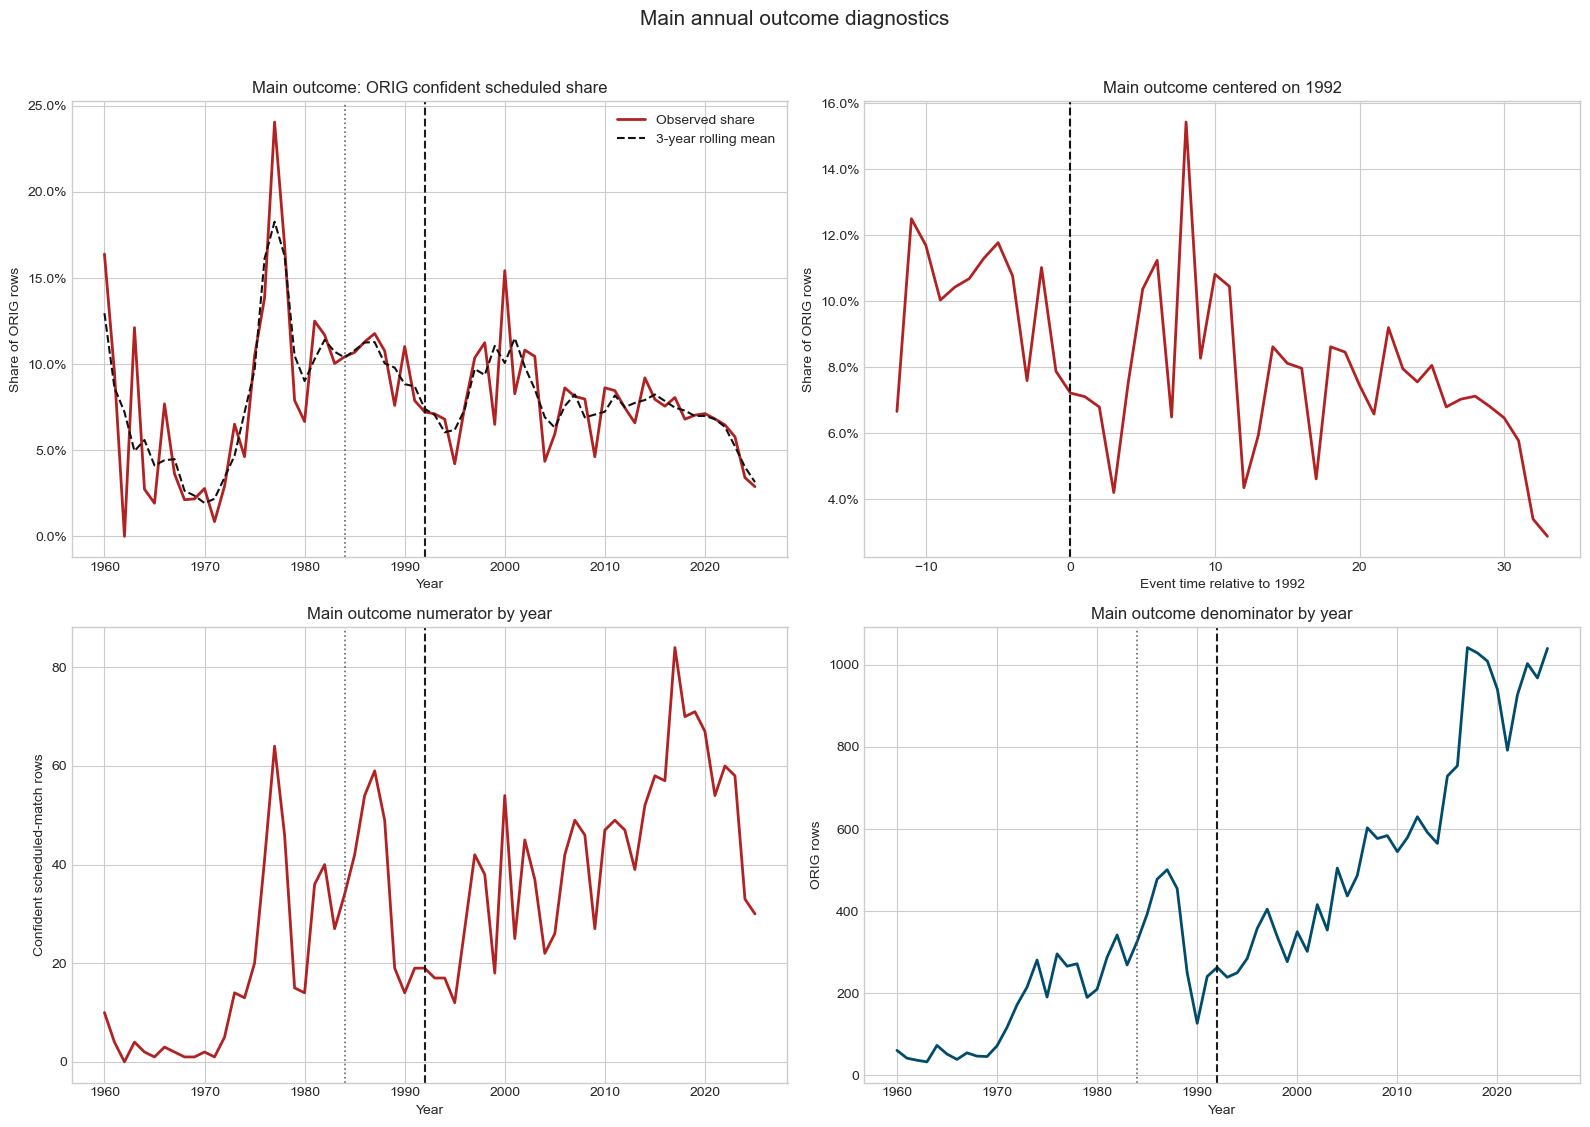

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Main share over calendar time.
axes[0, 0].plot(annual_panel["year"], annual_panel["orig_confident_share"], color="#b22222", linewidth=2, label="Observed share")
axes[0, 0].plot(annual_panel["year"], annual_panel["orig_confident_share_roll3"], color="#111111", linewidth=1.5, linestyle="--", label=f"{ROLLING_WINDOW}-year rolling mean")
add_policy_markers(axes[0, 0])
axes[0, 0].set_title("Main outcome: ORIG confident scheduled share")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Share of ORIG rows")
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[0, 0].legend(frameon=False)

# Event-time view centered on 1992.
centered = annual_panel.loc[annual_panel["year"].between(ESTIMATION_YEAR_MIN, YEAR_MAX)].copy()
axes[0, 1].plot(centered["event_time_1992"], centered["orig_confident_share"], color="#b22222", linewidth=2)
axes[0, 1].axvline(0, color="#111111", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Main outcome centered on 1992")
axes[0, 1].set_xlabel("Event time relative to 1992")
axes[0, 1].set_ylabel("Share of ORIG rows")
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Main numerator over time.
axes[1, 0].plot(annual_panel["year"], annual_panel["orig_confident_numerator"], color="#b22222", linewidth=2)
add_policy_markers(axes[1, 0])
axes[1, 0].set_title("Main outcome numerator by year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Confident scheduled-match rows")

# Main denominator over time.
axes[1, 1].plot(annual_panel["year"], annual_panel["orig_confident_denominator"], color="#004c6d", linewidth=2)
add_policy_markers(axes[1, 1])
axes[1, 1].set_title("Main outcome denominator by year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("ORIG rows")

fig.suptitle("Main annual outcome diagnostics", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()


### Interpretation

This figure answers a basic but important setup question: the main outcome is not just a denominator story.

The denominator rises substantially over time, especially after the early sparse decades, but the share itself also moves. That makes a share-based event-study setup more defensible than a raw-count-only design. At the same time, the series is clearly not a sharp one-time step function around 1992. Any modeling should therefore allow for trend changes rather than forcing a pure discontinuity story.


## Compare the main outcome to the structured sensitivity series

The next block compares the main series to the most relevant alternatives:

- `ORIG` confident scheduled share
- `AP` confident scheduled share
- `ORIG + NDA-only` confident scheduled share
- `ORIG` confident + `List I` share
- `ORIG` any DEA signal share

This is where the notebook verifies whether the main choice still dominates after direct time-series inspection.


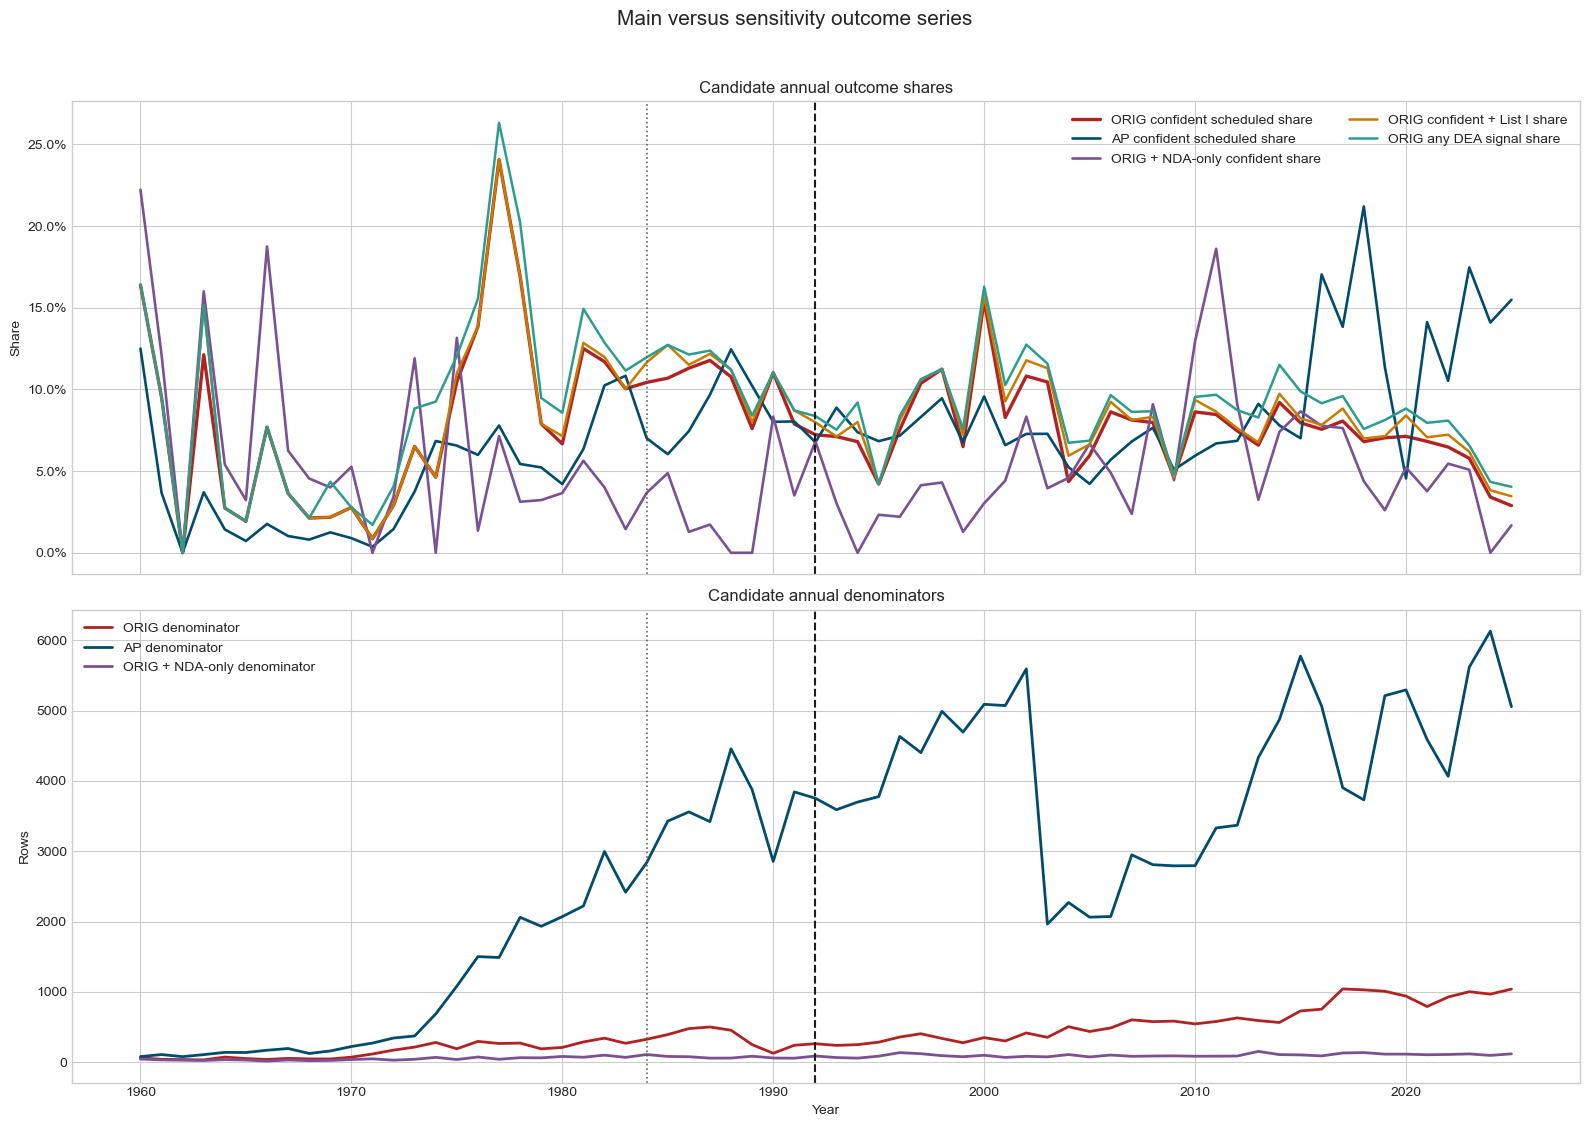

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

share_plot_specs = OrderedDict([
    ("orig_confident_share", {"label": "ORIG confident scheduled share", "color": "#b22222", "linewidth": 2.4}),
    ("ap_confident_share", {"label": "AP confident scheduled share", "color": "#004c6d", "linewidth": 1.9}),
    ("orig_nda_confident_share", {"label": "ORIG + NDA-only confident share", "color": "#7a5195", "linewidth": 1.9}),
    ("orig_confident_plus_list_i_share", {"label": "ORIG confident + List I share", "color": "#c97b00", "linewidth": 1.8}),
    ("orig_any_signal_share", {"label": "ORIG any DEA signal share", "color": "#2a9d8f", "linewidth": 1.8}),
])

for column, spec in share_plot_specs.items():
    axes[0].plot(annual_panel["year"], annual_panel[column], label=spec["label"], color=spec["color"], linewidth=spec["linewidth"])
add_policy_markers(axes[0])
axes[0].set_title("Candidate annual outcome shares")
axes[0].set_ylabel("Share")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[0].legend(frameon=False, ncol=2)

for denominator_col, label, color in [
    ("orig_confident_denominator", "ORIG denominator", "#b22222"),
    ("ap_confident_denominator", "AP denominator", "#004c6d"),
    ("orig_nda_confident_denominator", "ORIG + NDA-only denominator", "#7a5195"),
]:
    axes[1].plot(annual_panel["year"], annual_panel[denominator_col], label=label, color=color, linewidth=2)
add_policy_markers(axes[1])
axes[1].set_title("Candidate annual denominators")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Rows")
axes[1].legend(frameon=False)

fig.suptitle("Main versus sensitivity outcome series", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()


### Interpretation

This comparison reinforces the candidate-choice logic from notebook 04.

- `AP` confident share is smoother in some years only because the denominator is much larger, but that comes from reintroducing supplement-heavy activity.
- `ORIG + NDA-only` is more tightly aligned with a pure PDUFA channel, but the denominator is visibly much smaller and the share is much noisier.
- The broader ORIG-based sensitivity outcomes move in the same general range as the main series, which supports using the confident-only series in the main specification and broader DEA rules as sensitivity checks rather than as replacements.


## Estimate transparent first-pass interrupted-time-series style models

This notebook does **not** attempt a modern causal design that the data cannot support. Instead it uses simple interrupted-time-series style specifications that match the national annual panel we actually have.

The core first-pass models are:

- descriptive pre/post mean comparisons
- segmented trend models with a break at 1992
- a context model with a break at 1984 for the main series

These are run with HAC(1) standard errors as a minimal adjustment for serial dependence in an annual time series.


,series_label,mean_share_1980_1991,mean_share_1992_2005,mean_share_2006_2025,post_1992_minus_pre
0,ORIG confident scheduled share,0.1020,0.0831,0.0698,-0.0189
1,AP confident scheduled share,0.0838,0.0727,0.1042,-0.0111
2,ORIG + NDA-only confident scheduled share,0.0318,0.0393,0.0622,0.0076
3,ORIG confident + List I share,0.1075,0.0894,0.0738,-0.0181
4,ORIG any DEA signal share,0.1134,0.0940,0.0818,-0.0194


,series_label,break_year,window_label,term,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,ORIG confident scheduled share,1992,1980-2025,const,0.1059,0.0113,9.3952,0.0000,0.0838,0.1280
1,ORIG confident scheduled share,1992,1980-2025,time_index,-0.0007,0.0016,-0.4453,0.6561,-0.0038,0.0024
2,ORIG confident scheduled share,1992,1980-2025,post_1992,-0.0080,0.0133,-0.6008,0.5479,-0.0340,0.0180
3,ORIG confident scheduled share,1992,1980-2025,post_1992_trend,-0.0001,0.0017,-0.0884,0.9296,-0.0034,0.0031


,series_label,break_year,window_label,term,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,ORIG confident scheduled share,1992,1960-2025,const,0.0542,0.0207,2.6221,0.0087,0.0137,0.0948
1,ORIG confident scheduled share,1992,1960-2025,time_index,0.0020,0.0009,2.1452,0.0319,0.0002,0.0038
2,ORIG confident scheduled share,1992,1960-2025,post_1992,-0.0281,0.0174,-1.6115,0.1071,-0.0622,0.0061
3,ORIG confident scheduled share,1992,1960-2025,post_1992_trend,-0.0028,0.0010,-2.7201,0.0065,-0.0049,-0.0008


,series_label,break_year,window_label,term,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,ORIG confident scheduled share,1984,1980-2025,const,0.0883,0.0144,6.1132,0.0000,0.0600,0.1166
1,ORIG confident scheduled share,1984,1980-2025,time_index,0.0093,0.0069,1.3453,0.1785,-0.0043,0.0229
2,ORIG confident scheduled share,1984,1980-2025,post_1984,-0.0234,0.0191,-1.2281,0.2194,-0.0608,0.0140
3,ORIG confident scheduled share,1984,1980-2025,post_1984_trend,-0.0104,0.0069,-1.4985,0.1340,-0.0239,0.0032


,series_label,window_label,post_1992_coef,post_1992_p,post_1992_trend_coef,post_1992_trend_p,r_squared
0,ORIG confident scheduled share,1980-2025,-0.0080,0.5479,-0.0001,0.9296,0.3029
1,AP confident scheduled share,1980-2025,-0.0480,0.0039,-0.0003,0.8947,0.3091
2,ORIG + NDA-only confident scheduled share,1980-2025,0.0178,0.4042,0.0013,0.5571,0.0870
3,ORIG confident + List I share,1980-2025,-0.0079,0.5603,-0.0002,0.9254,0.3131
4,ORIG any DEA signal share,1980-2025,-0.0001,0.9934,0.0015,0.3496,0.2832


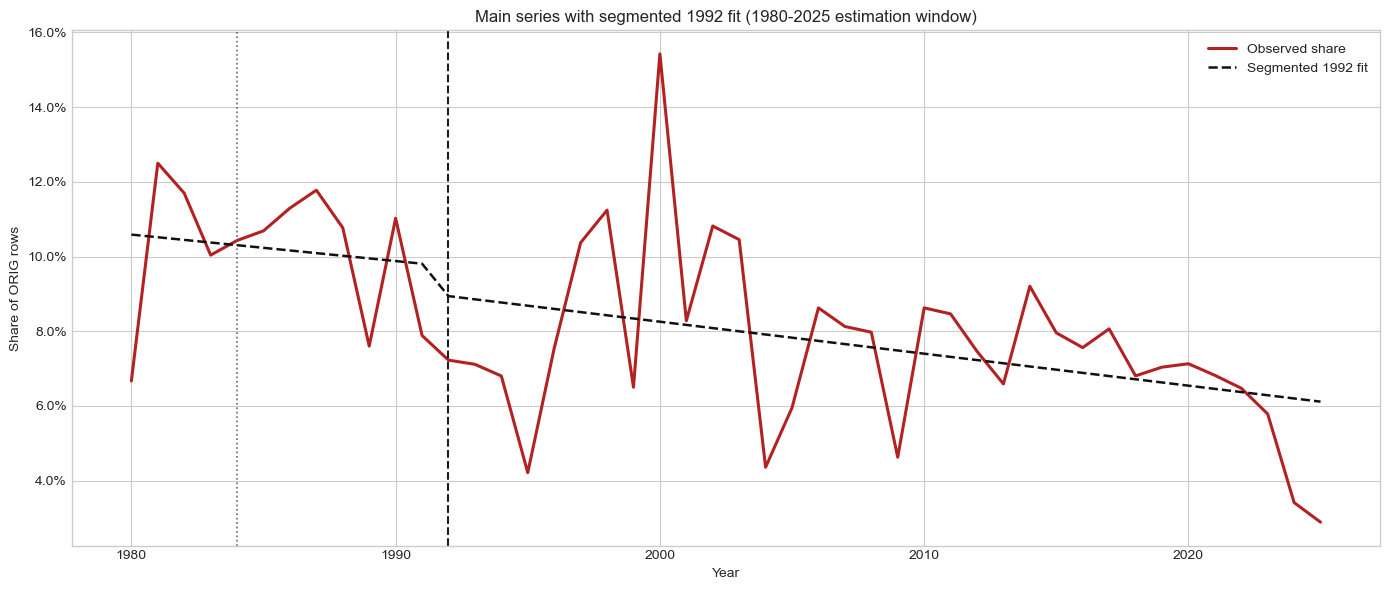

In [8]:
mean_comparison_rows = []
for series_key, spec in SERIES_SPECS.items():
    share_col = f"{series_key}_share"
    panel_est = annual_panel.loc[annual_panel["year"].between(ESTIMATION_YEAR_MIN, YEAR_MAX)].copy()
    mean_comparison_rows.append({
        "series_label": spec["label"],
        "mean_share_1980_1991": panel_est.loc[panel_est["year"].between(1980, 1991), share_col].mean(),
        "mean_share_1992_2005": panel_est.loc[panel_est["year"].between(1992, 2005), share_col].mean(),
        "mean_share_2006_2025": panel_est.loc[panel_est["year"].between(2006, 2025), share_col].mean(),
        "post_1992_minus_pre": panel_est.loc[panel_est["year"].between(1992, 2005), share_col].mean() - panel_est.loc[panel_est["year"].between(1980, 1991), share_col].mean(),
    })
mean_comparison_table = pd.DataFrame(mean_comparison_rows)

main_model_1980_df, main_model_1980 = fit_segmented_its(
    annual_panel,
    outcome_col="orig_confident_share",
    break_year=MAIN_BREAK_YEAR,
    year_min=ESTIMATION_YEAR_MIN,
    year_max=YEAR_MAX,
)

main_model_1960_df, main_model_1960 = fit_segmented_its(
    annual_panel,
    outcome_col="orig_confident_share",
    break_year=MAIN_BREAK_YEAR,
    year_min=DESCRIPTIVE_YEAR_MIN,
    year_max=YEAR_MAX,
)

main_model_1984_df, main_model_1984 = fit_segmented_its(
    annual_panel,
    outcome_col="orig_confident_share",
    break_year=CONTEXT_BREAK_YEAR,
    year_min=ESTIMATION_YEAR_MIN,
    year_max=YEAR_MAX,
)

sensitivity_models = []
for series_key, spec in SERIES_SPECS.items():
    model_df, model = fit_segmented_its(
        annual_panel,
        outcome_col=f"{series_key}_share",
        break_year=MAIN_BREAK_YEAR,
        year_min=ESTIMATION_YEAR_MIN,
        year_max=YEAR_MAX,
    )
    sensitivity_models.append({
        "series_label": spec["label"],
        "window_label": f"{ESTIMATION_YEAR_MIN}-{YEAR_MAX}",
        "post_1992_coef": model.params[f"post_{MAIN_BREAK_YEAR}"],
        "post_1992_p": model.pvalues[f"post_{MAIN_BREAK_YEAR}"],
        "post_1992_trend_coef": model.params[f"post_{MAIN_BREAK_YEAR}_trend"],
        "post_1992_trend_p": model.pvalues[f"post_{MAIN_BREAK_YEAR}_trend"],
        "r_squared": model.rsquared,
    })
sensitivity_model_table = pd.DataFrame(sensitivity_models)

main_model_table_1980 = extract_model_results(main_model_1980, "ORIG confident scheduled share", MAIN_BREAK_YEAR, f"{ESTIMATION_YEAR_MIN}-{YEAR_MAX}")
main_model_table_1960 = extract_model_results(main_model_1960, "ORIG confident scheduled share", MAIN_BREAK_YEAR, f"{DESCRIPTIVE_YEAR_MIN}-{YEAR_MAX}")
main_model_table_1984 = extract_model_results(main_model_1984, "ORIG confident scheduled share", CONTEXT_BREAK_YEAR, f"{ESTIMATION_YEAR_MIN}-{YEAR_MAX}")

display(mean_comparison_table)
display(main_model_table_1980)
display(main_model_table_1960)
display(main_model_table_1984)
display(sensitivity_model_table)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(main_model_1980_df["year"], main_model_1980_df["orig_confident_share"], color="#b22222", linewidth=2.2, label="Observed share")
ax.plot(main_model_1980_df["year"], main_model_1980_df["fitted_value"], color="#111111", linewidth=1.8, linestyle="--", label="Segmented 1992 fit")
add_policy_markers(ax)
ax.set_title("Main series with segmented 1992 fit (1980-2025 estimation window)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of ORIG rows")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Interpretation

These first-pass models should be read as disciplined diagnostics, not as strong causal estimates.

Three points matter most here:

1. The **1980–2025** segmented model is the most defensible first-pass window because it focuses on the policy-relevant era and avoids the sparsest early decades.
2. The main `ORIG` confident-share series does **not** produce a clean, dramatic 1992 break under that more disciplined window. That is important information: the cleaner series appears weaker statistically than some supplement-heavy alternatives.
3. The stronger-looking 1992 shift in the `AP` series is not automatically more credible, because it comes from a much more supplement-heavy sample that is less aligned with the core thesis motivation.

So the notebook keeps `ORIG` confident share as the main outcome not because it gives the sharpest result, but because it remains the most interpretable and least misleading first-pass series.


## Check whether later PDUFA renewals appear to create distinct new breaks

The notebook should not overbuild renewal analysis, but it should inspect whether the series suggests obvious additional shocks around major reauthorizations.

A light-touch diagnostic is appropriate here:

- mark the renewal years on the main series
- compare mean levels across broad policy eras

That is enough to see whether renewals look like distinct breaks or more like institutional continuation.


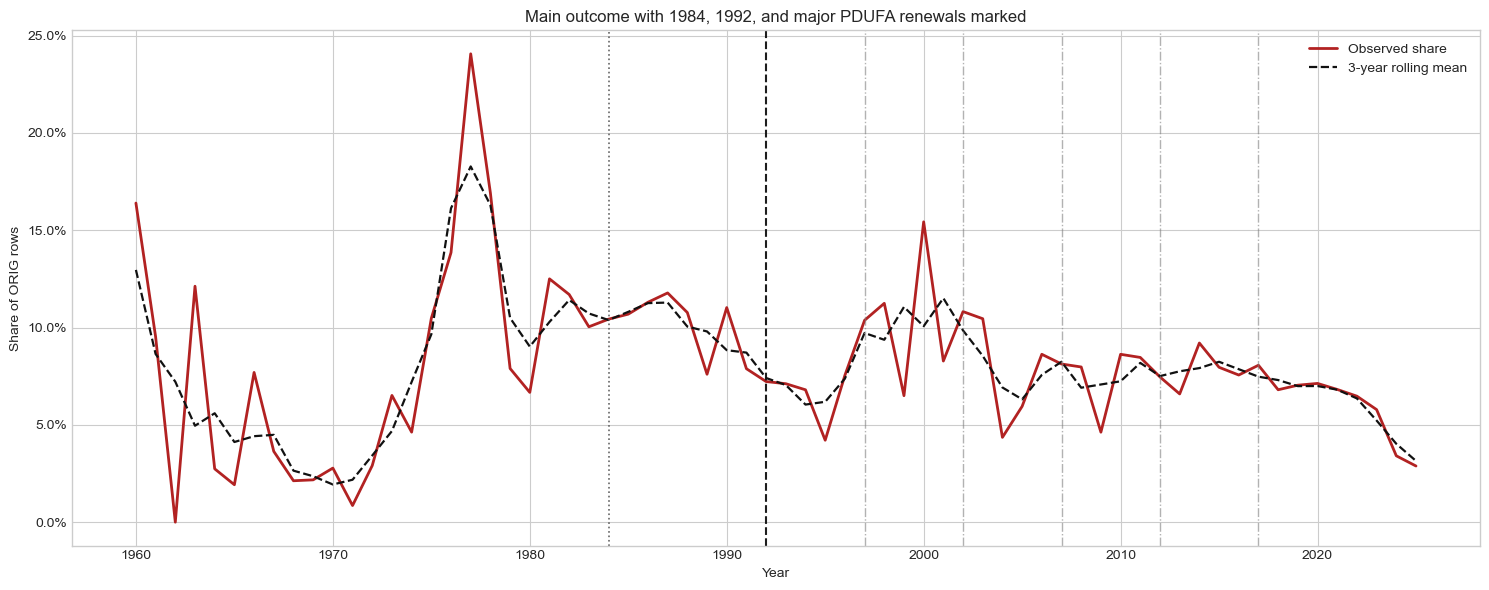

,policy_era,years,main_mean_share,main_mean_numerator,main_mean_denominator
0,1960-1983 pre-HW/PDUFA,24,0.0792,15.2500,152.7500
1,1984-1992 HW pre-PDUFA,9,0.0985,34.3333,337.1111
2,1993-1997 PDUFA I,5,0.0721,23.0000,307.4000
3,1998-2002 PDUFA II,5,0.1045,36.0000,336.6000
4,2003-2007 PDUFA III,5,0.0750,35.2000,477.2000
5,2008-2012 PDUFA IV,5,0.0743,43.2000,583.0000
6,2013-2017 PDUFA V,5,0.0787,58.0000,736.4000
7,2018-2025 PDUFA VI+,8,0.0579,55.3750,963.5000


In [9]:
policy_era_summary = (
    annual_panel.groupby("policy_era", observed=False)
    .agg(
        years=("year", "size"),
        main_mean_share=("orig_confident_share", "mean"),
        main_mean_numerator=("orig_confident_numerator", "mean"),
        main_mean_denominator=("orig_confident_denominator", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(annual_panel["year"], annual_panel["orig_confident_share"], color="#b22222", linewidth=2, label="Observed share")
ax.plot(annual_panel["year"], annual_panel["orig_confident_share_roll3"], color="#111111", linewidth=1.6, linestyle="--", label=f"{ROLLING_WINDOW}-year rolling mean")
add_policy_markers(ax, include_renewals=True)
ax.set_title("Main outcome with 1984, 1992, and major PDUFA renewals marked")
ax.set_xlabel("Year")
ax.set_ylabel("Share of ORIG rows")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(policy_era_summary)


### Interpretation

The renewal diagnostics do not suggest a simple sequence of clean new shocks layered on top of 1992. The main series moves across renewal eras, but the pattern looks more like institutional continuation mixed with noisy long-run composition changes than like a set of obvious discrete renewal breaks.

That supports a restrained design choice for now:

- treat **1992** as the main organizing event year
- treat later renewals as institutional continuation that should be acknowledged and marked visually
- leave more formal multi-break work for later only if the paper direction requires it


## Limitations of this first-pass event-study setup

This notebook should end by being explicit about what the setup can and cannot support.

### What it can support

- a transparent annual panel of FDA submission-event composition
- conservative comparison of controlled-substance-linked versus non-linked activity over time
- simple interrupted-time-series style diagnostics around 1992
- structured sensitivity comparisons across sample definitions and DEA confidence tiers

### What it cannot support cleanly

- strong causal identification of PDUFA effects
- product-level historical scheduling status at approval
- clean separation of PDUFA effects from broader market and regulatory changes
- a design that ignores Hatch-Waxman, generic expansion, and the strong `ANDA` contribution to the linked controlled-substance signal

### Why interpretation must remain cautious

- the FDA backbone is still a **submission-event** panel, not a distinct-drug panel
- the DEA linkage is still **ingredient-level, current, and non-historical**
- `ORIG + NDA-only` is conceptually closer to a pure PDUFA channel, but its annual denominator is small enough to make the series noisy
- `AP` delivers sharper-looking breaks partly because it reintroduces supplement inflation, not because it is automatically the cleaner causal sample
- the national annual time series is better understood as a first-pass interrupted-time-series design than as a modern event-study with strong quasi-experimental identification


## Next-step recommendations

1. Keep **`ORIG` confident scheduled DEA share** as the main first-pass event-study outcome for the next notebook or draft analysis.
2. Carry these structured sensitivity outcomes alongside it:
   - `ORIG + NDA-only` confident scheduled share
   - `ORIG` confident + `List I` share
   - `ORIG` any DEA signal share
   - `AP` confident share as a context series, not as the preferred main estimate
3. Use the exported annual panel as the stable input for the next paper-facing notebook rather than rebuilding annual series each time.
4. If the thesis narrows more tightly toward a PDUFA mechanism, consider a later dedicated notebook that focuses on `NDA`-aligned samples and explicitly discusses the cost of the smaller denominator.
5. If the paper continues with the broader controlled-substance composition question, prioritize clearer exposition of why `ORIG` is the least misleading main sample even when it produces less dramatic break estimates.
